In [1]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools, Descriptors, rdchem, rdMolDescriptors
import numpy as np
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV

def mol_to_feat(mol):
    #找我认为的重要键
    NO_single = NO_double = 0
    NN_single = NN_double = 0
    sum = 0
    for i in mol.GetBonds():
        pre = i.GetBeginAtom().GetSymbol()
        nxt = i.GetEndAtom().GetSymbol()
        link = i.GetBondType()
        if pre == "O":
            pre, nxt = nxt, pre
        if pre == "N" and nxt == "O":
            if link == rdchem.BondType.SINGLE:
                NO_single += 1
            else:
                NO_double += 1
        elif pre == "N" and nxt == "N":
            if link == rdchem.BondType.SINGLE:
                NN_single += 1
            else:
                NN_double += 1
        sum += 1

    #算各种原子的个数
    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()
    
    feat = [
        (C * 2 + H / 2 - O) * 16 / Descriptors.MolWt(mol),
        N * 14 / Descriptors.MolWt(mol),
        NO_single / sum, NO_double / sum,
        NN_single / sum, NN_double / sum
    ]
    return feat

file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)
x_all = np.stack(df["ROMol"].apply(mol_to_feat).tolist(), axis = 0)
y_all = np.array(df["Q(cal/g)"], dtype = np.float64)

for i in range(6):
    pipe = make_pipeline(PolynomialFeatures(i + 1), StandardScaler(), LassoCV(cv = 5))
    scores = cross_validate(pipe, x_all, y_all, cv = 10, scoring = ["neg_mean_squared_error", "r2"], n_jobs = -1)
    mse = np.abs(scores["test_neg_mean_squared_error"]).mean()
    r2 = scores["test_r2"].mean()
    print(i + 1, mse, r2, sep = ' ')


1 66942.96184910256 0.5424084342513057
2 54107.005851261216 0.6302357466581417
3 38881.19862583897 0.7806983361457942
4 35755.44242794518 0.7959127418760804
5 33161.25722538953 0.7879084754603213
6 36098.51196645266 0.7555870569743631


0.6046426050716053


,Num,Q(cal/g),SMILES,ROMol,predict
71,22,1597.739084,O=[N+]([O-])Nc1n[nH]c(-n2ncnc2[N+](=O)[O-])n1,,1628.977375
72,47,855.780288,O=C(Oc1noc(=O)n1O[N+](=O)[O-])N([N+](=O)[O-])[...,,1308.159470
73,71,919.495935,NC(=O)Oc1cc2nn[nH]c2cc1OC(=O)N[N+](=O)[O-],,1067.694159
74,36,1485.377528,O=C(c1ccc2c(c1)-n1c(nn([N+](=O)[O-])c1=O)CO2)N...,,1353.315259
75,79,1926.361753,O=[N+]([O-])Nc1c(C([N+](=O)[O-])[N+](=O)[O-])c...,,2111.564039
76,14,336.319289,NC(=O)Oc1c[nH]c(-c2nc(OC(N)=O)c[nH]2)n1,,652.037957
77,52,633.156169,NC(=O)On1c(C(N)=O)n[nH]c1=O,,967.047975
78,21,1958.031080,O=[N+]([O-])C(Oc1cn2nnn3c(OC([N+](=O)[O-])([N+...,,1674.747698
79,54,1272.495313,NC(=O)c1cn(C([N+](=O)[O-])[N+](=O)[O-])cn1,,1436.964769
80,77,1458.209463,O=[N+]([O-])C(Oc1nc(-c2nonc2C([N+](=O)[O-])([N...,,1628.286903

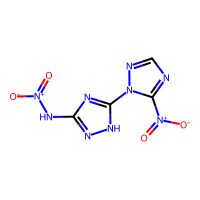
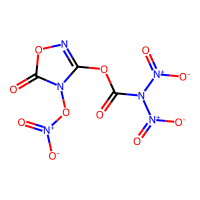
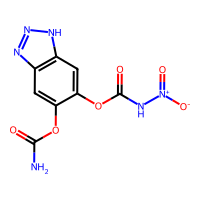
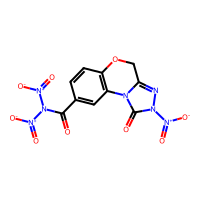
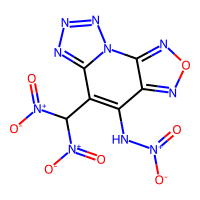
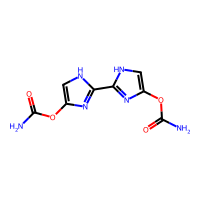
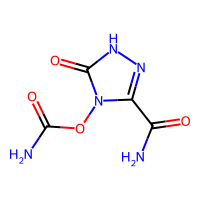
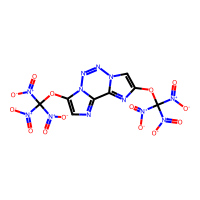
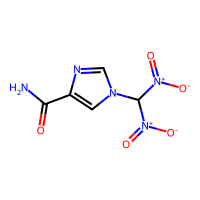
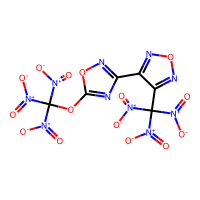
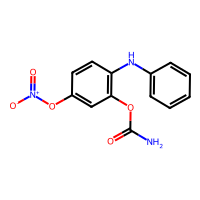
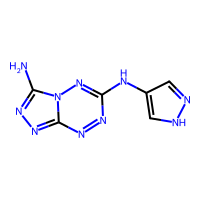
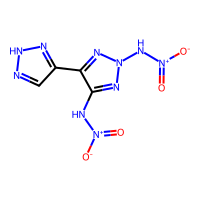
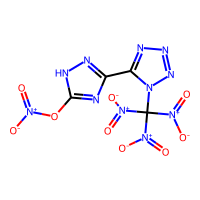
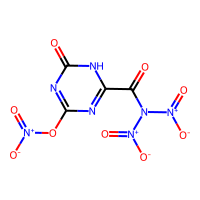
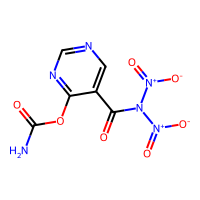
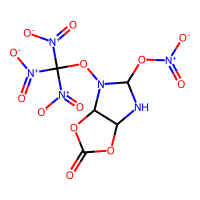

In [ ]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools, Descriptors, rdchem
import numpy as np
from sklearn.metrics import r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV

def mol_to_feat(mol):
    #找我认为的重要键
    NO_single = NO_double = 0
    NN_single = NN_double = 0
    sum = 0
    for i in mol.GetBonds():
        pre = i.GetBeginAtom().GetSymbol()
        nxt = i.GetEndAtom().GetSymbol()
        link = i.GetBondType()
        if pre == "O":
            pre, nxt = nxt, pre
        if pre == "N" and nxt == "O":
            if link == rdchem.BondType.SINGLE:
                NO_single += 1
            else:
                NO_double += 1
        elif pre == "N" and nxt == "N":
            if link == rdchem.BondType.SINGLE:
                NN_single += 1
            else:
                NN_double += 1
        sum += 1

    #算各种原子的个数
    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()

    feat = [
        (C * 2 + H / 2 - O) * 16 / Descriptors.MolWt(mol),
        N * 14 / Descriptors.MolWt(mol),
        NO_single / sum, NO_double / sum,
        NN_single / sum, NN_double / sum
    ]
    return feat

file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "ROMol", False)
df = df.sample(frac = 1, random_state = 323922, ignore_index = True)

x_train = np.stack(df["ROMol"][ : 71].apply(mol_to_feat).tolist(), axis = 0)
x_prac = np.stack(df["ROMol"][71 : ].apply(mol_to_feat).tolist(), axis = 0)
y_train = np.array(df["Q(cal/g)"][ : 71], dtype = np.float64)
y_prac = np.array(df["Q(cal/g)"][71 : ], dtype = np.float64)
pipe = make_pipeline(PolynomialFeatures(4), StandardScaler(), LassoCV(cv = 5, max_iter = 10000))
pipe.fit(x_train, y_train)
y_pre = pipe.predict(x_prac)

PandasTools.RenderImagesInAllDataFrames(images = True)
df1 = df[71 : ]
df1["predict"] = y_pre
print(r2_score(y_prac, y_pre))
df1

In [222]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, Descriptors, rdchem
import numpy as np

def mol_to_feat(mol):
    NO_single = NO_double = 0
    NN_single = NN_double = 0
    sum = 0
    for i in mol.GetBonds():
        pre = i.GetBeginAtom().GetSymbol()
        nxt = i.GetEndAtom().GetSymbol()
        link = i.GetBondType()
        if pre == "O":
            pre, nxt = nxt, pre
        if pre == "N" and nxt == "O":
            if link == rdchem.BondType.SINGLE:
                NO_single += 1
            else:
                NO_double += 1
        elif pre == "N" and nxt == "N":
            if link == rdchem.BondType.SINGLE:
                NN_single += 1
            else:
                NN_double += 1
        sum += 1

    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()

    feat = [
        (C * 2 + H / 2 - O) * 16 / Descriptors.MolWt(mol),
        N * 14 / Descriptors.MolWt(mol),
        NO_single / sum, NO_double / sum,
        NN_single / sum, NN_double / sum
    ]
    return feat
    

f = mol_to_feat(Chem.MolFromSmiles("O=[N+]([O-])Oc1nn2cnnc2n1O[N+](=O)[O-]"))
f

[0.03461944574267366,
 0.42408821034775235,
 0.29411764705882354,
 0.11764705882352941,
 0.0,
 0.11764705882352941]

,Num,Q(cal/g),SMILES,Molecule,Wt,Hf,OB*
6,7,2174.959096,O=[N+]([O-])Oc1nn2cnnc2n1O[N+](=O)[O-],,231.084,5.019387,0.450053
47,48,2145.061784,O=[N+]([O-])Oc1nonc1-c1nonc1C([N+](=O)[O-])[N+...,,303.103,5.489553,0.554267
40,41,2143.315211,O=[N+]([O-])c1c(OC([N+](=O)[O-])([N+](=O)[O-])...,,372.122,5.120632,0.601953
62,63,2125.180409,O=C(N[N+](=O)[O-])c1nonc1/N=N/c1nonc1C([N+](=O...,,403.14,5.103438,0.496106
67,68,2123.962637,O=C(c1nonc1Oc1nonc1C([N+](=O)[O-])[N+](=O)[O-]...,,391.125,5.983765,0.511345
18,19,2104.753276,NN1c2nonc2N(C([N+](=O)[O-])([N+](=O)[O-])[N+](...,,330.133,4.120461,0.533118
5,6,1987.835622,NC1=NOC(c2nonc2O[N+](=O)[O-])=NO1,,230.096,4.201724,0.625826
20,21,1958.031080,O=[N+]([O-])C(Oc1cn2nnn3c(OC([N+](=O)[O-])([N+...,,490.174,5.183465,0.554905
78,79,1926.361753,O=[N+]([O-])Nc1c(C([N+](=O)[O-])[N+](=O)[O-])c...,,326.145,2.774226,0.637753
69,70,1894.054371,O=C(c1nc(C(OC([N+](=O)[O-])([N+](=O)[O-])[N+](...,,449.169,5.118786,0.480888

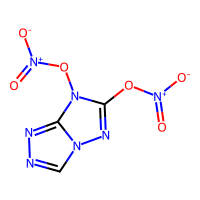
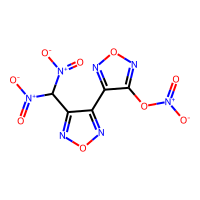
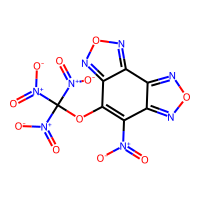
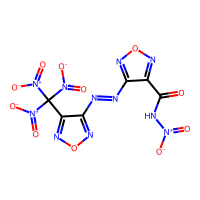
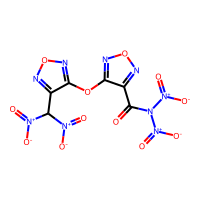
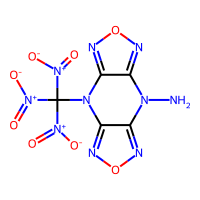
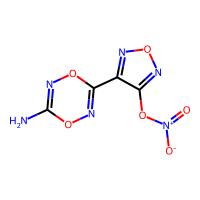
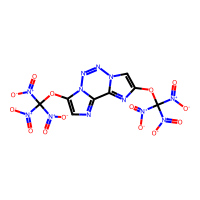
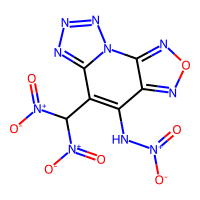
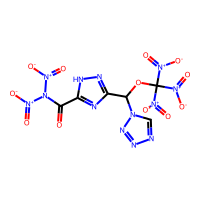
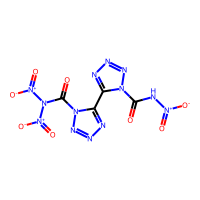
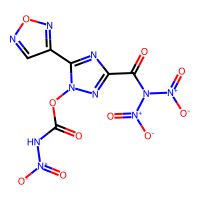
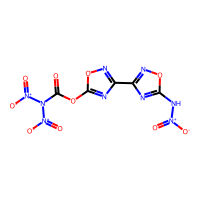
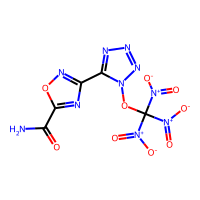
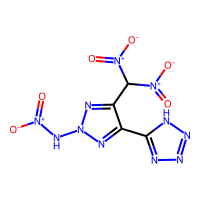
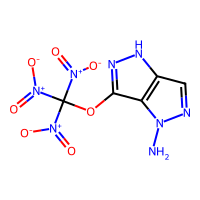
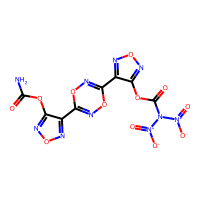
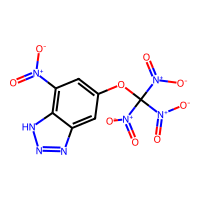
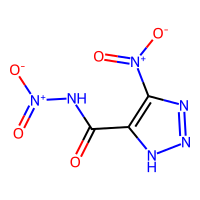
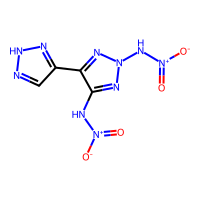
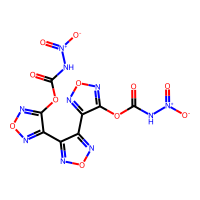
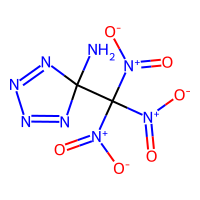
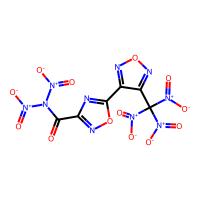
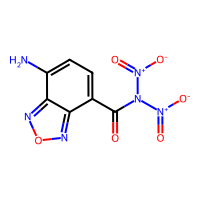
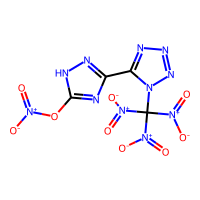
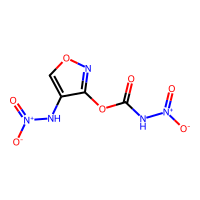
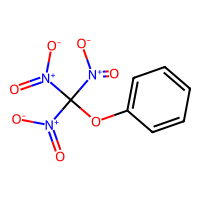
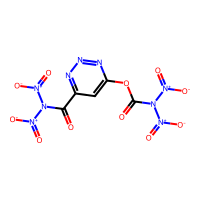
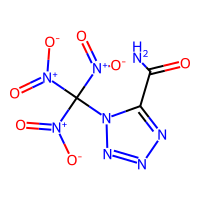
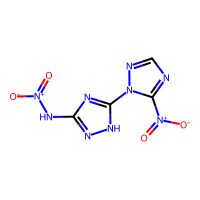
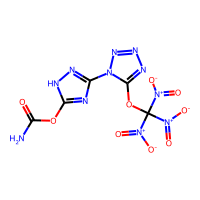
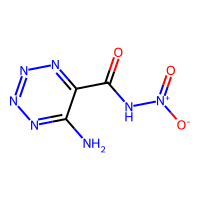
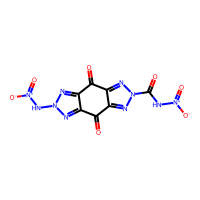
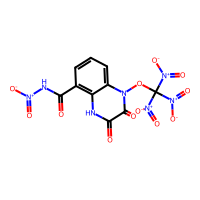
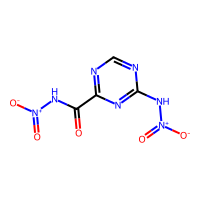
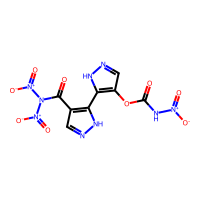
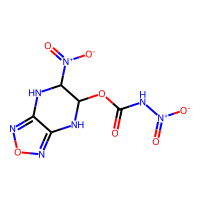
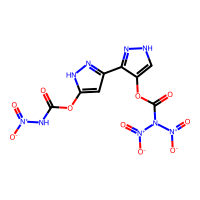
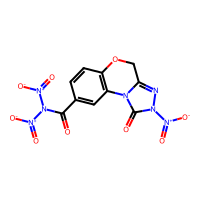
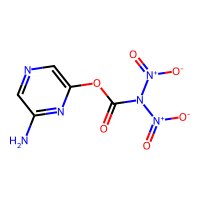
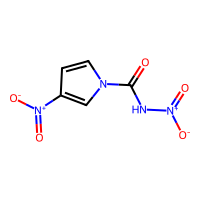
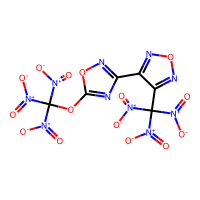
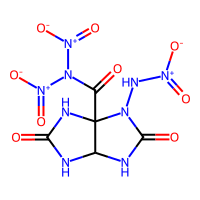
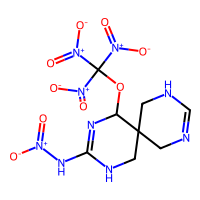
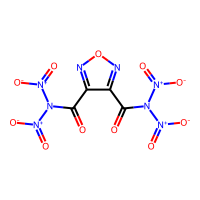
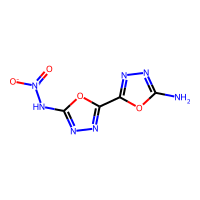
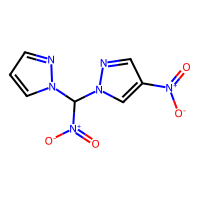
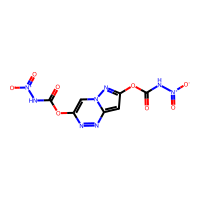
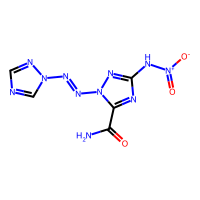
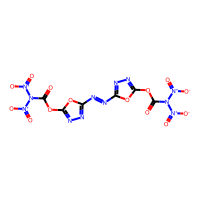
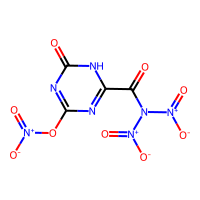
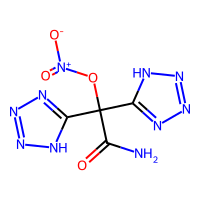
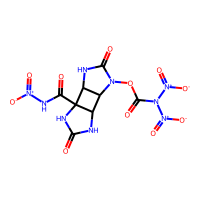
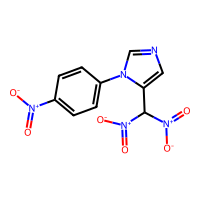
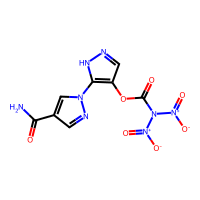
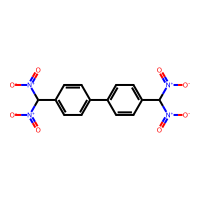
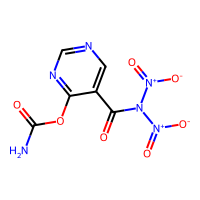
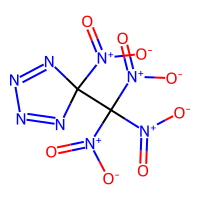
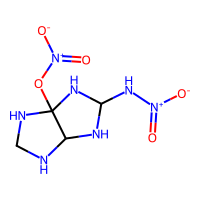
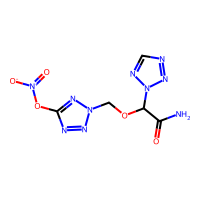
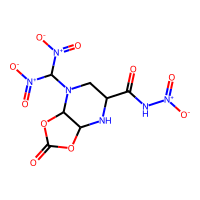
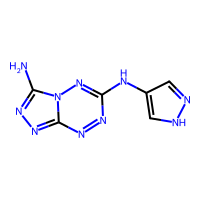
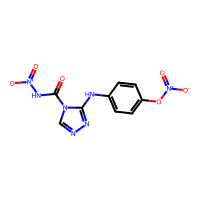
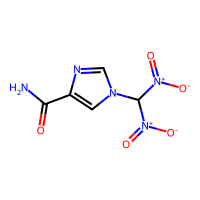
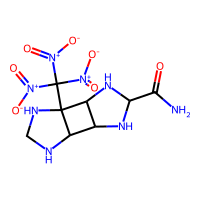
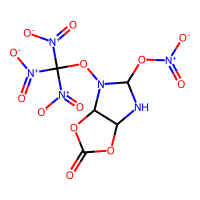
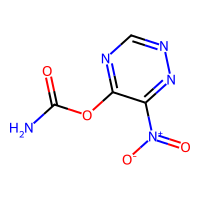
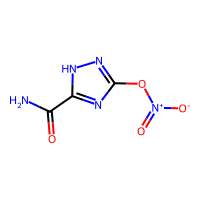
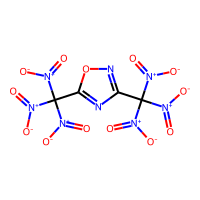
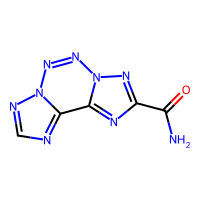
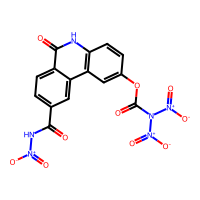
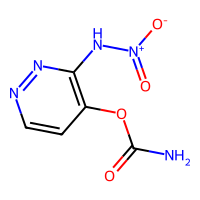
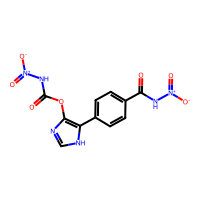
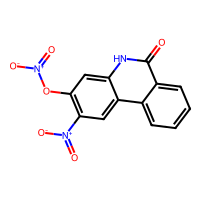
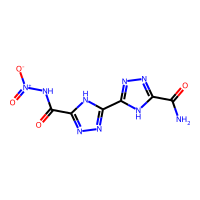
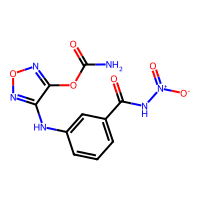
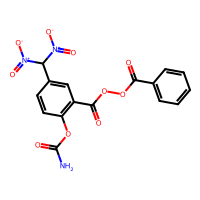
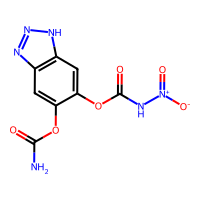
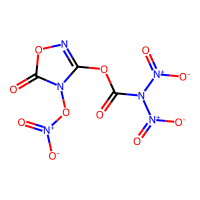
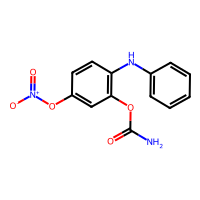
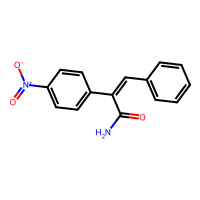
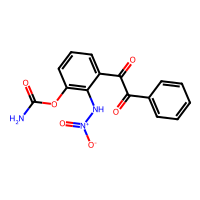
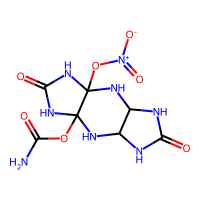
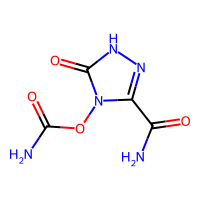
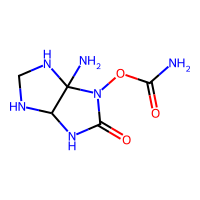
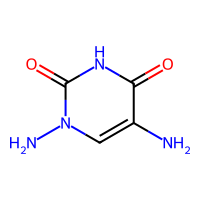
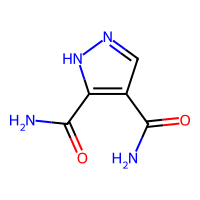
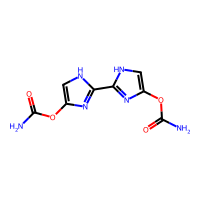

In [ ]:
from pathlib import Path
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools

def mol_to_feat(mol):
    mqn = rdMolDescriptors.MQNs_(mol)
    N = mqn[7] + mqn[8]
    O = mqn[9] + mqn[10]
    C = mqn[0]
    mol = Chem.AddHs(mol)
    H = mol.GetNumAtoms() - mol.GetNumHeavyAtoms()

    #粗算产物生成焓
    Hf = 0
    #H转变成H2O
    if H / 2 >= O:
        Hf += O * 241.8
        O = 0
    else:
        Hf += H / 2 * 241.8
        O -= H / 2
    #C转变成CO
    if C >= O:
        Hf += O * 110.5
        O = 0
    else:
        Hf += C * 110.5
        O -= C
    #CO转变成CO2
    if C >= O:
        Hf += O * 283
        O = 0
    else:
        Hf += C * 283
        O -= C
    #氧富裕需要施加惩罚
    if O > 0:
        Hf -= O * 10
    
    return [Hf / Descriptors.MolWt(mol), (C * 2 + H / 2 - O) * 16 / Descriptors.MolWt(mol)]

file = Path.cwd().parent / "data" / "test.xlsx"
df = pd.read_excel(file)
df = df.sort_values("Q(cal/g)", ascending = False)
PandasTools.AddMoleculeColumnToFrame(df, "SMILES", "Molecule")
df["Wt"] = df["Hf"] = df["OB*"] = None
for i in range(len(df)):
    df.loc[i, "Wt"] = Descriptors.MolWt(df.loc[i, "Molecule"])
    feat = mol_to_feat(df["Molecule"][i])
    df.loc[i, "Hf"] = feat[0]
    df.loc[i, "OB*"] = feat[1]
df

In [150]:
from rdkit import Chem
from rdkit.Chem import Descriptors
m = Chem.MolFromSmiles("Nc1cn(N)c(=O)[nH]c1=O")
print(Descriptors.MolWt(m))

142.118
